In [315]:
# Importing necessary libraries
import pandas as pd
import numpy as np

### **Importing the Dataset**

Use this if you don't have dataset on your local machine

In [316]:
# %pip install kagglehub # installing kaggle hub if missing

In [317]:

# import kagglehub
# import os
# # Download latest version
# path = kagglehub.dataset_download("zusmani/pakistans-largest-ecommerce-dataset")
# csv_path = os.path.join(path,'Pakistan Largest Ecommerce Dataset.csv')
# df = pd.read_csv(csv_path)


In [318]:
# If you have dataset on your own macine in the same directory where this notebook is placed
# df = pd.read_csv('Pakistan Largest Ecommerce Dataset.csv')

In [319]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [320]:
df = pd.read_csv('drive/MyDrive/Datasets/Pakistan Largest Ecommerce Dataset.csv')

/tmp/ipython-input-3924254085.py:1: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('drive/MyDrive/Datasets/Pakistan Largest Ecommerce Dataset.csv')


# **Understanding the data**

In [321]:
df.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [322]:
df.shape

(1048575, 26)

In [323]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-

# **Data Cleaning and Wrangling**

## **Dropping Columns**

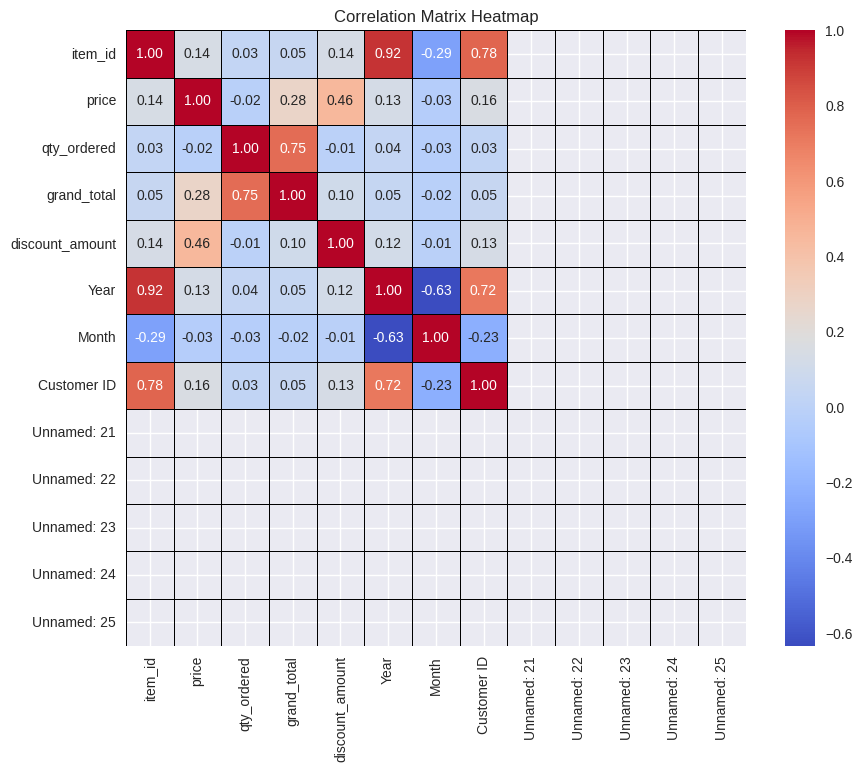

In [324]:
# First of all checking correlation among different columns
import seaborn as sns
import matplotlib.pyplot as plt

# The .corr() method calculates the Pearson correlation coefficient by default.
correlation_matrix = df.corr(numeric_only=True)
# Set the figure size for better visibility
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,         # Show the correlation values on the heatmap
    cmap='coolwarm',    # Choose a color palette (coolwarm is great for correlations)
    fmt='.2f',          # Format the annotations to 2 decimal places
    linewidths=0.5,     # Add lines between cells for clarity
    linecolor='black',
    cbar=True           # Show the color bar
)

# Add a title and display the plot
plt.title('Correlation Matrix Heatmap')
plt.show()

Dropping the Unnamed Columns  
They have 0 non-null values so they contribute nothing to our knowledge

In [325]:
df.drop(['Unnamed: 21','Unnamed: 22','Unnamed: 23','Unnamed: 24','Unnamed: 25'],axis = 1,inplace = True)

Removing the ID's Columns  
As they add nothing to our Analytical knowledge

In [326]:
df.drop(['increment_id'],axis = 1,inplace = True)

In [327]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   category_name_1        584360 non-null  object 
 8   sales_commission_code  447346 non-null  object 
 9   discount_amount        584524 non-null  float64
 10  payment_method         584524 non-null  object 
 11  Working Date           584524 non-null  object 
 12  BI Status              584524 non-null  object 
 13   MV                    584524 non-null  object 
 14  Year                   584524 non-

Checking for other redundant Columns

In [328]:
print(df['Month'].unique())
print(df['Year'].unique())

[ 7.  8.  9. 10. 11. 12.  1.  2.  3.  4.  5.  6. nan]
[2016. 2017. 2018.   nan]


In [329]:
df['M-Y'].unique()

array(['7-2016', '8-2016', '9-2016', '10-2016', '11-2016', '12-2016',
       '1-2017', '2-2017', '3-2017', '4-2017', '5-2017', '6-2017',
       '7-2017', '8-2017', '9-2017', '10-2017', '11-2017', '12-2017',
       '2-2018', '1-2018', '3-2018', '4-2018', '5-2018', '6-2018',
       '7-2018', '8-2018', nan], dtype=object)

#### Dropping the M-Y column as it redundant
It is just a composition of Month and year of order  

In [330]:
df.drop(['M-Y'],axis = 1,inplace = True)

#### Dropping the Month and Year as they can be inferred from the created_at date  

In [331]:
df.drop(['Month'],axis = 1,inplace = True)
df.drop(['Year'],axis = 1,inplace = True)

#### Dropping the working date colum as it is same as created_at which makes it redundant

In [332]:
df.drop(['Working Date'],axis = 1,inplace = True)

In [333]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   category_name_1        584360 non-null  object 
 8   sales_commission_code  447346 non-null  object 
 9   discount_amount        584524 non-null  float64
 10  payment_method         584524 non-null  object 
 11  BI Status              584524 non-null  object 
 12   MV                    584524 non-null  object 
 13  Customer Since         584513 non-null  object 
 14  FY                     584524 non-

## **DataTypes according to the data in the fields**
This will also help us in optimizing space usage per row

In [334]:
# Using snake case for all the column names

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [335]:
df = df.rename(columns={'category_name_1': 'category_name'})

In [336]:
df['status'] = df['status'].astype('category') # Converting order status datatype to category
df['category_name'] = df['category_name'].astype('category')
df['bi_status'] = df['bi_status'].astype('category')
# MV column contains , to convert it into integer we first have to remove the ,
df['mv'] = df['mv'].str.strip().str.replace(',', '')
df['mv'] = pd.to_numeric(df['mv'], errors='coerce')
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['customer_since'] = pd.to_datetime(df['customer_since'], errors='coerce')
# quantity can't be 2.5 or 3.5 it would be an integer
# Integer takes less space then float
df['qty_ordered'] = df['qty_ordered'].astype('Int32')



In [337]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   item_id                584524 non-null  float64       
 1   status                 584509 non-null  category      
 2   created_at             584524 non-null  datetime64[ns]
 3   sku                    584504 non-null  object        
 4   price                  584524 non-null  float64       
 5   qty_ordered            584524 non-null  Int32         
 6   grand_total            584524 non-null  float64       
 7   category_name          584360 non-null  category      
 8   sales_commission_code  447346 non-null  object        
 9   discount_amount        584524 non-null  float64       
 10  payment_method         584524 non-null  object        
 11  bi_status              584524 non-null  category      
 12  mv                     582292 non-null  fl

## **Removing the Duplicated Rows**

In [338]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.duplicated().sum())
df.shape

464050
0


(584525, 16)

## **Catering with the null values**

In [339]:
df.isnull().sum()

,0
item_id,1
status,16
created_at,1
sku,21
price,1
qty_ordered,1
grand_total,1
category_name,165
sales_commission_code,137179
discount_amount,1


In [340]:
# Percentage of Null values across all the columns
print(df.isnull().sum()/df.shape[0]*100)

item_id                   0.000171
status                    0.002737
created_at                0.000171
sku                       0.003593
price                     0.000171
qty_ordered               0.000171
grand_total               0.000171
category_name             0.028228
sales_commission_code    23.468457
discount_amount           0.000171
payment_method            0.000171
bi_status                 0.000171
mv                        0.382020
customer_since            0.002053
fy                        0.000171
customer_id               0.002053
dtype: float64


In [341]:
# Price has only one null value
df[df['price'].isnull()] # the whole row is null

,item_id,status,created_at,sku,price,qty_ordered,grand_total,category_name,sales_commission_code,discount_amount,payment_method,bi_status,mv,customer_since,fy,customer_id
584524,NaN,NaN,NaT,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN


In [342]:
# Removing the row where price is null
df = df[~df['price'].isnull()]

#### Dealing with remainng Null values

In [343]:
# Bi Status
df['bi_status'].value_counts()

,count
bi_status,
Net,234178
Gross,201454
Valid,148891
#REF!,1


In [344]:
# Replacing the !REF with mode of the column
mode_value = df['bi_status'][df['bi_status'] != "#REF!"].mode().iloc[0]
df['bi_status'] = df['bi_status'].replace("#REF!", mode_value)

/tmp/ipython-input-1169988518.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['bi_status'] = df['bi_status'].replace("#REF!", mode_value)


In [345]:
# Category and sku
df['category_name'].unique()

['Women's Fashion', 'Beauty & Grooming', 'Soghaat', 'Mobiles & Tablets', 'Appliances', ..., 'Superstore', 'Health & Sports', 'Books', 'School & Education', NaN]
Length: 17
Categories (16, object): ['Appliances', 'Beauty & Grooming', 'Books', 'Computing', ..., 'Soghaat',
                          'Superstore', 'Women's Fashion', '\N']

In [346]:
# At first replace \\N values with null
df['category_name'] = df['category_name'].replace('\\N', np.nan)

/tmp/ipython-input-3431527502.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['category_name'] = df['category_name'].replace('\\N', np.nan)


In [347]:
# we can infer category from sku (stock keeping unit)
df[df['sku'].isnull()]

,item_id,status,created_at,sku,price,qty_ordered,grand_total,category_name,sales_commission_code,discount_amount,payment_method,bi_status,mv,customer_since,fy,customer_id
14846,230008.0,canceled,2016-08-13,NaN,0.0,1,0.0,NaN,\N,0.0,cod,Gross,NaN,2016-08-01,FY17,3468.0
20676,236830.0,canceled,2016-09-01,NaN,0.0,1,0.0,NaN,\N,0.0,cod,Gross,NaN,2016-08-01,FY17,4369.0
39838,260006.0,canceled,2016-10-07,NaN,0.0,1,0.0,NaN,\N,0.0,cod,Gross,NaN,2016-07-01,FY17,939.0
39839,260007.0,canceled,2016-10-07,NaN,0.0,3,0.0,NaN,\N,0.0,cod,Gross,NaN,2016-07-01,FY17,939.0
39880,260061.0,canceled,2016-10-07,NaN,0.0,3,0.0,NaN,\N,0.0,cod,Gross,NaN,2016-07-01,FY17,939.0
124968,367292.0,refund,2016-12-10,NaN,0.0,1,0.0,NaN,\N,0.0,cod,Valid,NaN,2016-11-01,FY17,26305.0
125636,368122.0,refund,2016-12-12,NaN,0.0,1,0.0,NaN,\N,0.0,cod,Valid,NaN,2016-07-01,FY17,2246.0
125811,368362.0,refund,2016-12-13,NaN,0.0,1,0.0,NaN,\N,0.0,cod,Valid,NaN,2016-07-01,FY17,251.0
149597,399798.0,refund,2017-02-07,NaN,0.0,1,0.0,NaN,\N,0.0,cod,Valid,NaN,2017-02-01,FY17,33062.0
170249,426105.0,canceled,2017-03-21,NaN,0.0,1,6952.0,NaN,\N,0.0,cod,Gross,NaN,2017-03-01,FY17,38242.0


In [348]:
# We can infer category name and sku from each other
# but if they both are null we can drop those rows as
# from the dataset analysis it is known that the other columns in these rows are also null
df = df.dropna(subset=['sku', 'category_name'], how='all')

In [349]:
df.isnull().sum()

,0
item_id,0
status,15
created_at,0
sku,3
price,0
qty_ordered,0
grand_total,0
category_name,7997
sales_commission_code,137178
discount_amount,0


In [350]:
# ONly 3 sku values are null so fill them with unkown
df['sku'] = df['sku'].fillna('Unknown')

In [352]:
# 1. Create a mapping Series:
sku_to_category_map = df.groupby('sku')['category_name'].first()

# 2. Apply the mapping to fill missing values:
#    For every row where 'category_name' is missing (NaN),
#    Pandas looks up the corresponding 'sku' in the map and fills the NaN.

df['category_name'] = df['category_name'].fillna(df['sku'].map(sku_to_category_map))

In [353]:
# For those missing valeus where the sku can't determine the category name cuz we can't find any similar sku with same category
df['category_name'] = df['category_name'].fillna('Others')


In [354]:
# Sales Comission Code
len(df['sales_commission_code'].unique()) # This column is not useful for our analysis
# Just filling it now later on we will decide weather to remove it or keep it
df['sales_commission_code'] = df['sales_commission_code'].fillna('Unknown')

In [355]:
# Imputing MV(merchandise value i:e the amount the merchandise would get) its the price without any adjustments including discount
df["mv"] = (df["price"] * df["qty_ordered"])

In [356]:
df.isnull().sum()

,0
item_id,0
status,15
created_at,0
sku,0
price,0
qty_ordered,0
grand_total,0
category_name,0
sales_commission_code,0
discount_amount,0


## **Resolving Inconsistencies in the data**

In [357]:
## Inconsistencies over here
df['status'].value_counts()

,count
status,
complete,233685
canceled,201241
received,77290
order_refunded,59529
refund,8042
cod,2858
paid,1159
closed,494
payment_review,57


In [358]:
df['status'] = df['status'].astype(str).str.strip().str.lower().replace({'\\n': np.nan, 'nan': np.nan})

status_map = {
    "complete": "completed",
    "received": "completed",
    "paid": "completed",

    "canceled": "cancelled",
    "closed": "cancelled",

    "order_refunded": "refunded",
    "refund": "refunded",
    "exchange": "refunded",   # exchange is similar to return/refund

    "processing": "processing",
    "payment_review": "processing",

    "pending": "pending",
    "pending_paypal": "pending",
    "holded": "pending",
    "fraud": np.nan,
    'cod': np.nan, # Cod is a payment method not order status
    'other':np.nan
}

df['status'] = df['status'].map(status_map)
# df['status'] = df['status'].fillna('other')
mode_value = df['status'].mode().iloc[0]
df['status'] = df['status'].fillna(mode_value)


In [359]:
df['status'].value_counts()

,count
status,
completed,315021
cancelled,201735
refunded,67575
processing,90
pending,86


In [360]:
# as the pending and processing has very few counts approximately less than 0.1% of the total dataset values
# so combining them to order status 'others'

status_map = {
    "pending": "others",
    "processing": "others"
}

df['status'] = df['status'].replace(status_map)


In [361]:
print(df['status'].unique()) # Now the status column is Ready

['completed' 'cancelled' 'refunded' 'others']


In [362]:
df.isnull().sum()

,0
item_id,0
status,0
created_at,0
sku,0
price,0
qty_ordered,0
grand_total,0
category_name,0
sales_commission_code,0
discount_amount,0


In [363]:
df.sample(5)

,item_id,status,created_at,sku,price,qty_ordered,grand_total,category_name,sales_commission_code,discount_amount,payment_method,bi_status,mv,customer_since,fy,customer_id
312050,591259.0,cancelled,2017-10-10,ENTECO59CB906983CC5,18800.0,1,15800.00,Entertainment,\N,3000.00,Easypay,Gross,18800.0,2016-11-01,FY18,23978.0
1526,212879.0,completed,2016-07-07,audionic6-954217-562582,585.0,1,74.00,Computing,\N,0.00,cod,Net,585.0,2016-07-01,FY17,621.0
300362,577729.0,cancelled,2017-09-06,Geepas_GAC9445,14740.0,1,14740.00,Appliances,\N,0.00,Payaxis,Gross,14740.0,2017-08-01,FY18,60142.0
146283,395212.0,cancelled,2017-01-30,bata_wein-8838137-42-8,3499.0,1,16494.00,Men's Fashion,\N,0.00,cod,Gross,3499.0,2017-01-01,FY17,30624.0
96951,331115.0,refunded,2016-11-25,UnzeLondon_GS5221-7,1999.0,1,1699.15,Men's Fashion,\N,299.85,jazzwallet,Valid,1999.0,2016-11-01,FY17,20136.0


In [364]:
# Resolving inconsistencies in payment method column
df['payment_method'].unique()

array(['cod', 'ublcreditcard', 'mygateway', 'customercredit',
       'cashatdoorstep', 'mcblite', 'internetbanking', 'marketingexpense',
       'productcredit', 'financesettlement', 'Payaxis', 'jazzvoucher',
       'jazzwallet', 'Easypay', 'Easypay_MA', 'easypay_voucher',
       'bankalfalah', 'apg'], dtype=object)

In [365]:
df['payment_method'].value_counts()

,count
payment_method,
cod,271943
Payaxis,97641
Easypay,82900
jazzwallet,35145
easypay_voucher,31176
bankalfalah,23065
jazzvoucher,15633
Easypay_MA,14028
customercredit,7555


In [366]:

payment_map = {
    "cod": "COD",
    "cashatdoorstep": "COD",

    "ublcreditcard": "Credit/Debit Card",
    "bankalfalah": "Credit/Debit Card",
    "mygateway": "Credit/Debit Card",
    "apg": "Credit/Debit Card",

    "internetbanking": "Internet Banking",
    "mcblite": "Internet Banking",
    "Payaxis": "Payaxis",

    "Easypay": "Easypay",
    "Easypay_MA": "Easypay",
    "easypay_voucher": "Easypay",

    "jazzwallet": "JazzCash",
    "jazzvoucher": "JazzCash",



    "customercredit": "Store Credit",
    "productcredit": "Store Credit",
    "financesettlement": "Store Credit",
    "marketingexpense": "Store Credit",
}
df["payment_method_clean"] = df["payment_method"].map(payment_map)



In [367]:
df['payment_method_clean'].unique()

array(['COD', 'Credit/Debit Card', 'Store Credit', 'Internet Banking',
       'Payaxis', 'JazzCash', 'Easypay'], dtype=object)

In [368]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584507 entries, 0 to 584523
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   item_id                584507 non-null  float64       
 1   status                 584507 non-null  object        
 2   created_at             584507 non-null  datetime64[ns]
 3   sku                    584507 non-null  object        
 4   price                  584507 non-null  float64       
 5   qty_ordered            584507 non-null  Int32         
 6   grand_total            584507 non-null  float64       
 7   category_name          584507 non-null  category      
 8   sales_commission_code  584507 non-null  object        
 9   discount_amount        584507 non-null  float64       
 10  payment_method         584507 non-null  object        
 11  bi_status              584507 non-null  category      
 12  mv                     584507 non-null  Float64  

In [369]:
df[df['discount_amount']>(df['price'] * df['qty_ordered'])]

,item_id,status,created_at,sku,price,qty_ordered,grand_total,category_name,sales_commission_code,discount_amount,payment_method,bi_status,mv,customer_since,fy,customer_id,payment_method_clean
155307,407448.0,completed,2017-02-20,Nimcos_Mix-Nimco-200gm,110.0,1,604.25,Soghaat,\N,200.3750,Payaxis,Net,110.0,2016-11-01,FY17,26790.0,Payaxis
155511,407718.0,completed,2017-02-21,Aladdin_Hand Grip Pair - Black,269.0,1,4321.40,Health & Sports,HDD105640,381.3000,Payaxis,Net,269.0,2017-02-01,FY17,34446.0,Payaxis
155648,407892.0,completed,2017-02-21,sg_KajalPencil0.36g,100.0,1,683.29,Beauty & Grooming,\N,138.2367,Payaxis,Net,100.0,2016-11-01,FY17,26620.0,Payaxis
158368,411348.0,completed,2017-02-27,tram_TT23080083,55.0,2,637.40,Home & Living,\N,203.3000,Payaxis,Net,110.0,2016-11-01,FY17,26413.0,Payaxis
159975,413387.0,completed,2017-03-02,swi_LTLP,10.0,1,604.25,School & Education,C-PEW-31067,133.5833,Payaxis,Net,10.0,2016-11-01,FY17,27151.0,Payaxis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584414,905090.0,refunded,2018-08-27,MATMY5A4A253C8A5C2,48.0,2,326.01,Mobiles & Tablets,Unknown,299.9900,cod,Valid,96.0,2017-11-01,FY19,69407.0,COD
584415,905091.0,refunded,2018-08-27,MATBIZ5A702C575969E,145.0,1,326.01,Mobiles & Tablets,Unknown,299.9900,cod,Valid,145.0,2017-11-01,FY19,69407.0,COD
584416,905092.0,refunded,2018-08-27,MEFEZI5B7169B92D153,275.0,1,326.01,Men's Fashion,Unknown,299.9900,cod,Valid,275.0,2017-11-01,FY19,69407.0,COD
584417,905093.0,refunded,2018-08-27,HASQAR5A618CC063535,189.0,1,326.01,Health & Sports,Unknown,299.9900,cod,Valid,189.0,2017-11-01,FY19,69407.0,COD


In [370]:
# Assuming where discount is greatere than the price*qty_ordered the intention was to give 100% discount
# 1. Calculate the maximum valid discount (price * quantity ordered) for all rows.
max_discount_value = df['price'] * df['qty_ordered']

# 2. Use the condition directly in .loc to select the problematic rows
#    and assign the calculated 'max_discount_value' to the 'discount_amount' column.
df.loc[df['discount_amount'] > max_discount_value, 'discount_amount'] = max_discount_value

In [371]:
df[df['grand_total']<0] # 75 rows are such that where grand_total is less negative
# inconsistency -> it can't be possible


,item_id,status,created_at,sku,price,qty_ordered,grand_total,category_name,sales_commission_code,discount_amount,payment_method,bi_status,mv,customer_since,fy,customer_id,payment_method_clean
209940,473144.0,completed,2017-05-19,lalassc_SSP-07A,1200.0,1,-10.0,Women's Fashion,\N,300.0000,Payaxis,Net,1200.0,2016-11-01,FY17,15714.0,Payaxis
242331,510950.0,completed,2017-06-12,SN_Muzadati-500gm,170.0,1,-6.4,Soghaat,\N,74.8095,Easypay,Valid,170.0,2016-07-01,FY17,967.0,Easypay
242332,510951.0,completed,2017-06-12,Nimcos_Namak-Paray-200gm,98.0,2,-6.4,Soghaat,\N,86.2510,Easypay,Valid,196.0,2016-07-01,FY17,967.0,Easypay
242333,510952.0,completed,2017-06-12,Nimcos_Crunchy-Mix-400gm,216.0,1,-6.4,Soghaat,\N,95.0521,Easypay,Valid,216.0,2016-07-01,FY17,967.0,Easypay
242334,510953.0,completed,2017-06-12,RS_Sohan Halwa 1000gm,660.0,1,-6.4,Soghaat,\N,290.4370,Easypay,Valid,660.0,2016-07-01,FY17,967.0,Easypay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571270,890219.0,completed,2018-07-27,MEFOXF5B39EF5CC541E-M,420.0,1,-340.6,Men's Fashion,Unknown,420.0000,bankalfalah,Net,420.0,2016-08-01,FY19,3732.0,Credit/Debit Card
571271,890221.0,completed,2018-07-27,VIT5AC4A6E65D6C6,180.0,1,-340.6,Superstore,Unknown,180.0000,bankalfalah,Net,180.0,2016-08-01,FY19,3732.0,Credit/Debit Card
571272,890222.0,completed,2018-07-27,HIJ5B2204D154E0F,450.0,1,-340.6,Superstore,Unknown,450.0000,bankalfalah,Net,450.0,2016-08-01,FY19,3732.0,Credit/Debit Card
571273,890223.0,completed,2018-07-27,HASQAR5A53699375950,98.0,4,-340.6,Health & Sports,Unknown,392.0000,bankalfalah,Net,392.0,2016-08-01,FY19,3732.0,Credit/Debit Card


In [372]:
df.loc[df['grand_total'] < 0, 'grand_total'] = (
    df['price'] * df['qty_ordered'] - df['discount_amount']
)


In [373]:
print(len(df[df['grand_total']<0]))

0


In [374]:
df[df['discount_amount']<0]

,item_id,status,created_at,sku,price,qty_ordered,grand_total,category_name,sales_commission_code,discount_amount,payment_method,bi_status,mv,customer_since,fy,customer_id,payment_method_clean
152474,403716.0,cancelled,2017-02-13,akl-GFSU1265-M,5995.0,1,5395.5,Women's Fashion,\N,-599.5,Payaxis,Gross,5995.0,2016-07-01,FY17,73.0,Payaxis
152478,403730.0,refunded,2017-02-13,test-product,4.0,2,156.0,Others,\N,-2.0,Payaxis,Valid,8.0,2016-07-01,FY17,1423.0,Payaxis
152479,403731.0,cancelled,2017-02-13,RB_HouseholdBundle,1000.0,5,4998.0,Superstore,\N,-2.0,Payaxis,Gross,5000.0,2016-07-01,FY17,73.0,Payaxis


In [375]:
neg_mask = df['discount_amount'] < 0
df.loc[neg_mask, 'discount_amount'] = 0
df.loc[neg_mask, 'grand_total'] = (
    df.loc[neg_mask, 'price'] * df.loc[neg_mask, 'qty_ordered']
)




In [376]:
print(len(df[df['discount_amount']<0]))

0


In [377]:
df.describe()

,item_id,created_at,price,qty_ordered,grand_total,discount_amount,mv,customer_since,customer_id
count,584507.000000,584507,5.845070e+05,584507.0,5.845070e+05,584507.000000,584507.0,584496,584496.000000
mean,565672.533148,2017-08-08 11:51:08.672231424,6.348932e+03,1.296388,8.531226e+03,461.472515,7177.515405,2017-04-24 19:04:50.613452288,45791.414540
min,211131.000000,2016-07-01 00:00:00,0.000000e+00,1.0,0.000000e+00,0.000000,0.0,2016-07-01 00:00:00,1.000000
25%,395005.000000,2017-01-29 00:00:00,3.600000e+02,1.0,9.450000e+02,0.000000,399.0,2016-11-01 00:00:00,13516.000000
50%,568432.000000,2017-08-17 00:00:00,8.990000e+02,1.0,1.960912e+03,0.000000,999.0,2017-04-01 00:00:00,42856.000000
75%,739110.500000,2018-02-03 00:00:00,4.070000e+03,1.0,6.999000e+03,150.402700,5000.0,2017-11-01 00:00:00,73537.000000
max,905208.000000,2018-08-28 00:00:00,1.012626e+06,1000.0,1.788800e+07,90300.000000,8944000.0,2018-08-01 00:00:00,115326.000000
std,200120.823584,NaN,1.494945e+04,3.996118,6.132170e+04,1424.820082,33947.803833,NaN,34414.932809


In [378]:
df.to_csv("cleaned_dataset.csv", index=False)

In [379]:
import pandas as pd
df = pd.read_csv('cleaned_dataset.csv')

# **Exploratory Data Analysis**

In [380]:
import matplotlib.pyplot as plt
# plt.style.use('default')
# Set your style at the very start
plt.style.use('seaborn-v0_8')

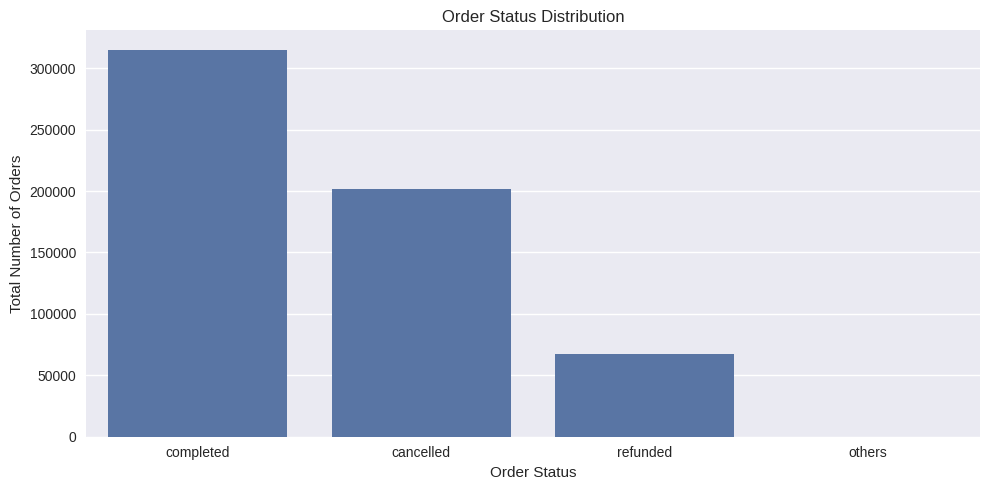

In [381]:
# Firstly let's check the overall distribution of orders How many orders were cancelled how many were completed
# The completion rate of orders
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='status', order=df['status'].value_counts().index)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Total Number of Orders')
plt.tight_layout()
plt.show()


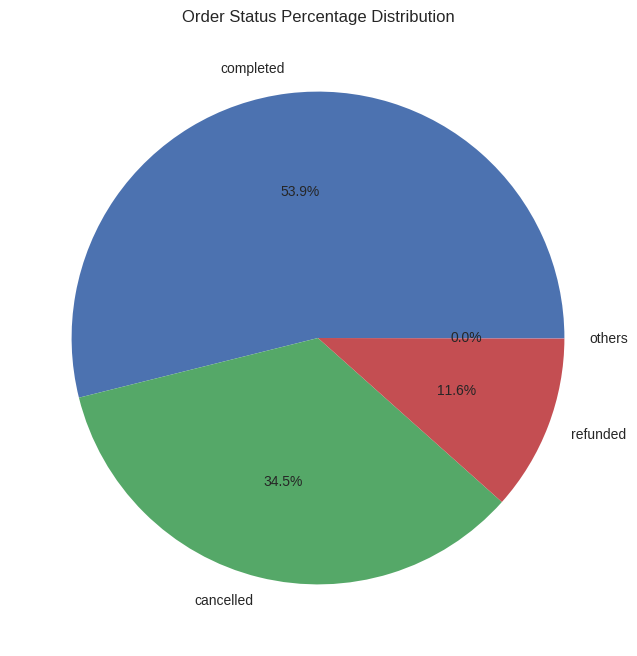

In [382]:
status_counts = df['status'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
plt.title('Order Status Percentage Distribution')
plt.show()

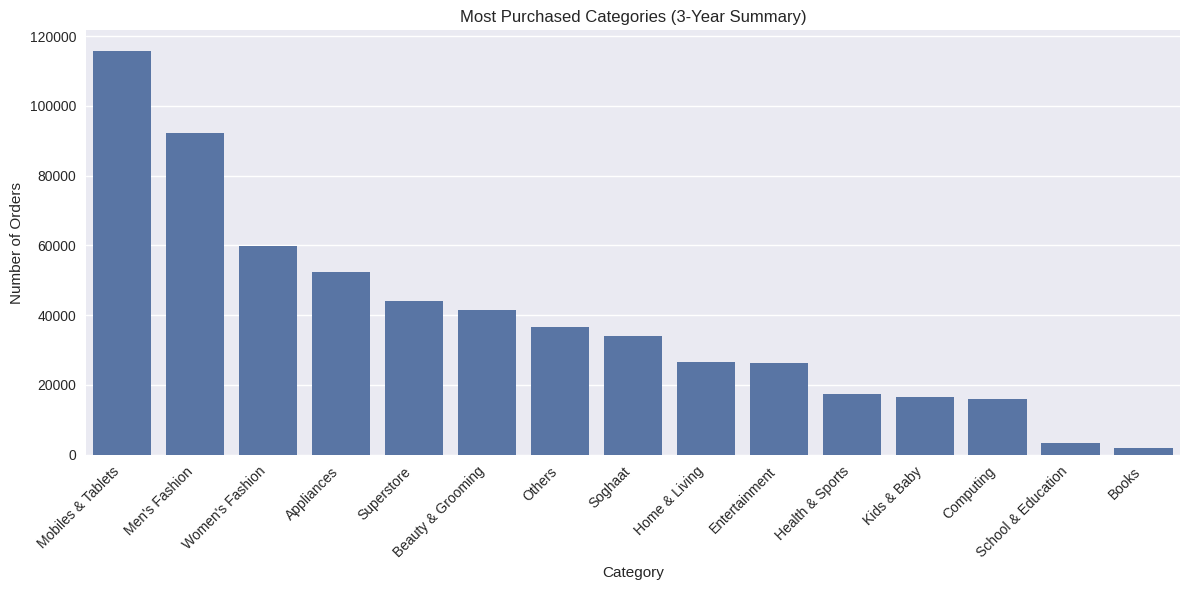

In [383]:
# Checking which category is the most sold one throughout these three years
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='category_name',
    order=df['category_name'].value_counts().index
)

plt.title("Most Purchased Categories (3-Year Summary)")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


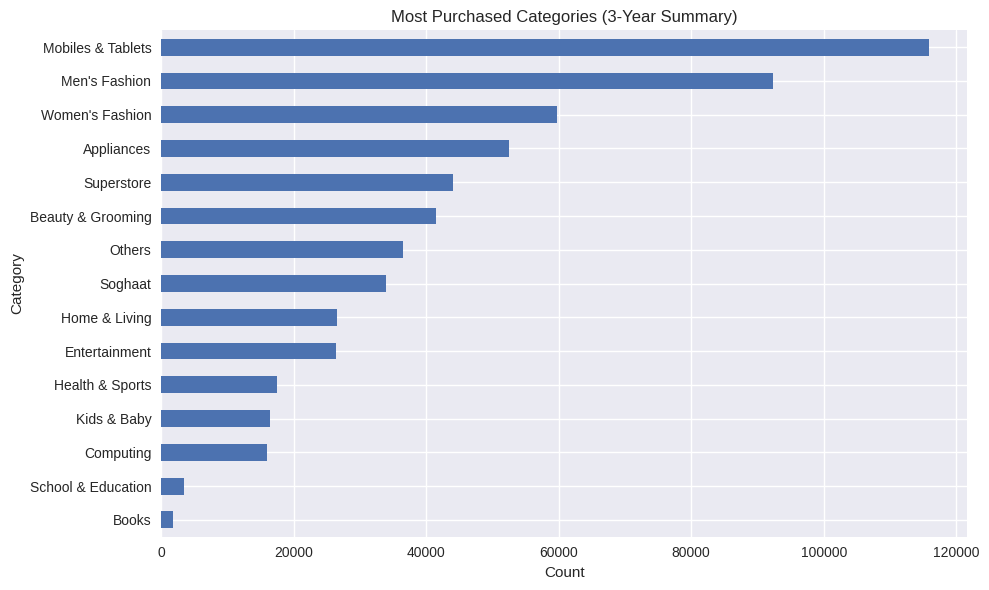

In [384]:
# As sir don't like rotations on x-axis we can make horizontal bar-chart Decide in group which one to keep as final version
plt.figure(figsize=(10,6))
df['category_name'].value_counts().sort_values(ascending=True).plot(kind='barh')

plt.title("Most Purchased Categories (3-Year Summary)")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


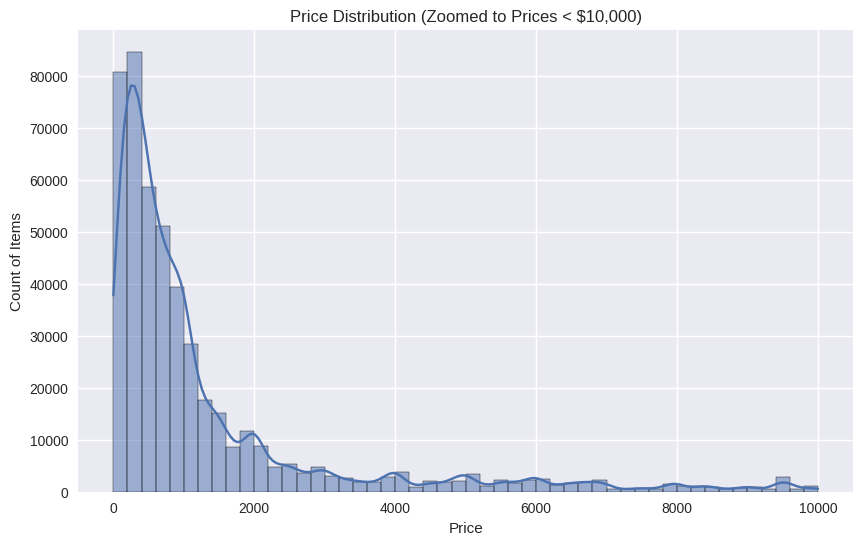

In [385]:
# Checking the price distribution of each product listed online and purchased by customer i:e not price of full order which would be price*qty


# Focus the histogram on prices up to the 95th percentile (e.g., $10,000)
# to clearly see the distribution of the majority of products.
limit = 10000

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df[df['price'] < limit], # Filter the data for visualization
    x='price',
    bins=50,
    kde=True # Add a kernel density estimate line
)
plt.title(f'Price Distribution (Zoomed to Prices < ${limit:,.0f})')
plt.xlabel('Price')
plt.ylabel('Count of Items')
plt.show()

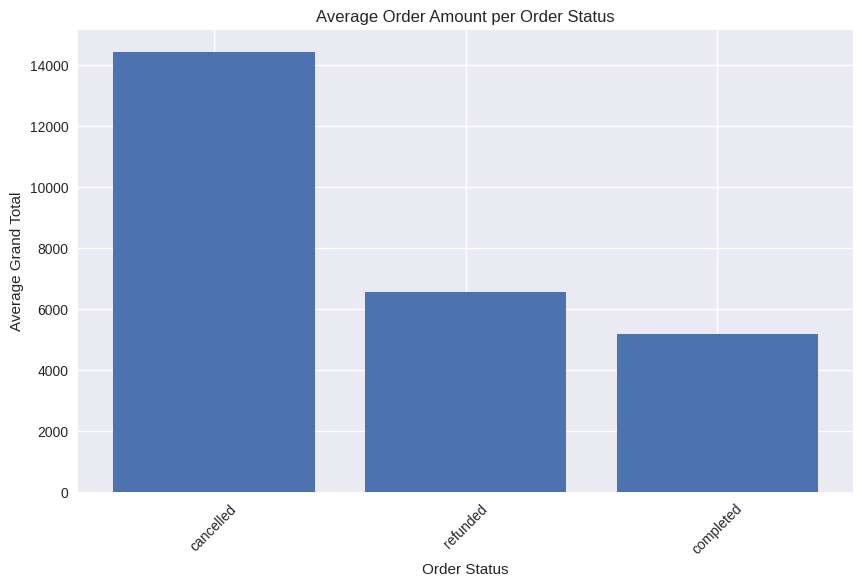

In [386]:
# compute average order amount per status
# Does cancelled orders have really high price


df_filtered = df[df['status']!='others']
status_amount = df_filtered.groupby('status')['grand_total'].mean().reset_index()

# sort by amount (optional for neat visualization)
status_amount = status_amount.sort_values('grand_total', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(status_amount['status'], status_amount['grand_total'])
plt.xticks(rotation=45)
plt.ylabel("Average Grand Total")
plt.xlabel("Order Status")
plt.title("Average Order Amount per Order Status")
plt.show()


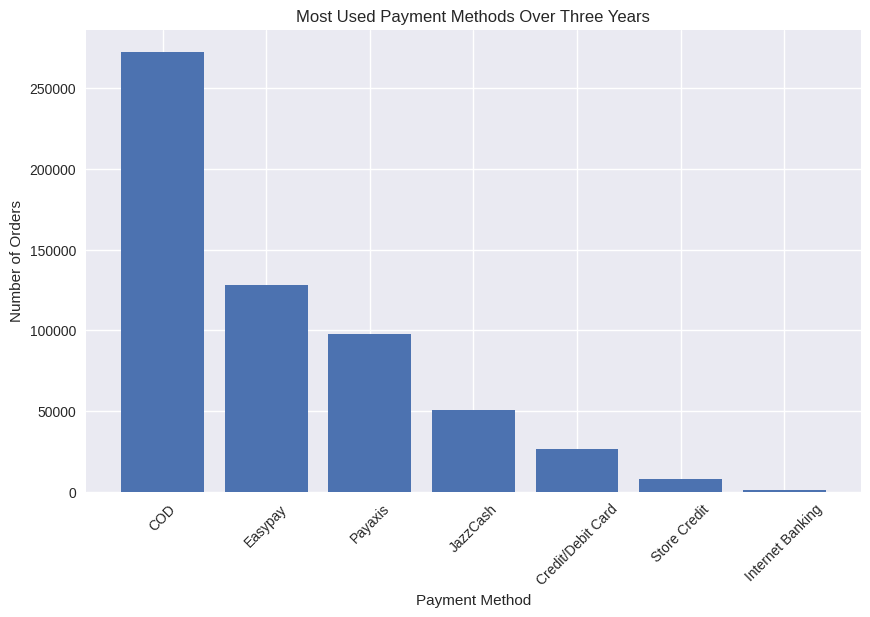

In [387]:
# Which payment method is the most popular
pm_counts = df['payment_method_clean'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(pm_counts.index, pm_counts.values)
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.xlabel("Payment Method")
plt.title("Most Used Payment Methods Over Three Years")
plt.show()


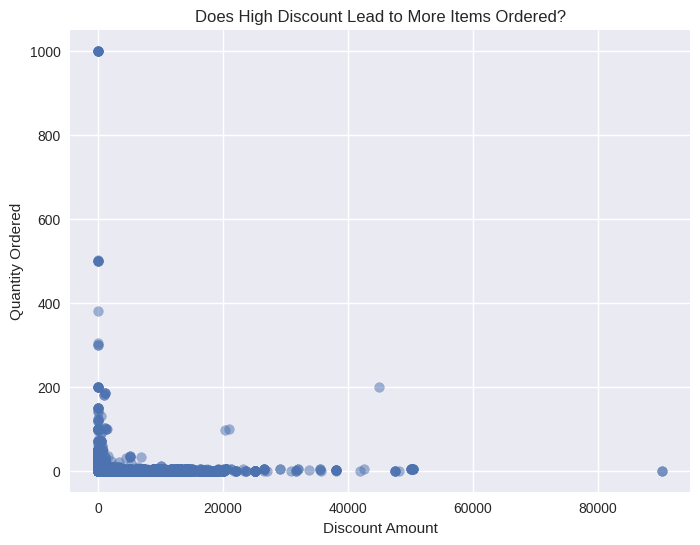

In [388]:
# Does high discount leads to more number of items ordered?

plt.figure(figsize=(8,6))
plt.scatter(df['discount_amount'], df['qty_ordered'], alpha=0.5)
plt.xlabel("Discount Amount")
plt.ylabel("Quantity Ordered")
plt.title("Does High Discount Lead to More Items Ordered?")
plt.show()

In [389]:
df['grand_total'].describe()

,grand_total
count,5.845070e+05
mean,8.531226e+03
std,6.132170e+04
min,0.000000e+00
25%,9.450000e+02
50%,1.960912e+03
75%,6.999000e+03
max,1.788800e+07


/tmp/ipython-input-261925522.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['price_bin', 'payment_method_clean']).size().unstack().plot(kind='bar')


<Figure size 1000x600 with 0 Axes>

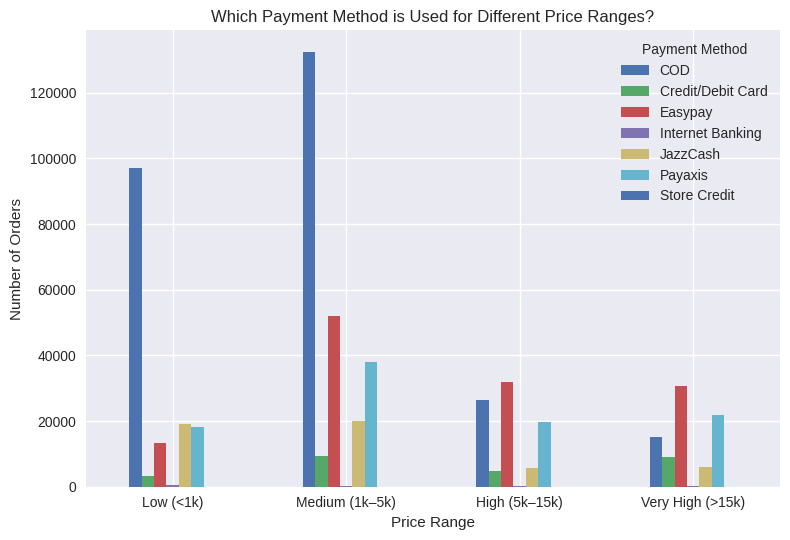

In [390]:
# Does people prefers to pay high order amount through COD
# Create price bins

bins = [0, 1000, 5000, 15000, df['grand_total'].max()]
labels = ['Low (<1k)', 'Medium (1k–5k)', 'High (5k–15k)', 'Very High (>15k)']

df['price_bin'] = pd.cut(df['grand_total'], bins=bins, labels=labels)

# Plot
plt.figure(figsize=(10,6))
df.groupby(['price_bin', 'payment_method_clean']).size().unstack().plot(kind='bar')

plt.xlabel("Price Range")
plt.ylabel("Number of Orders")
plt.title("Which Payment Method is Used for Different Price Ranges?")
plt.xticks(rotation=0)
plt.legend(title="Payment Method")
plt.tight_layout()
plt.show()


In [392]:
df['customer_age_months'] = ((df['created_at'] - df['customer_since']).dt.days) /30

In [393]:
df['num_orders'] = df.groupby('customer_id')['customer_id'].transform('count')


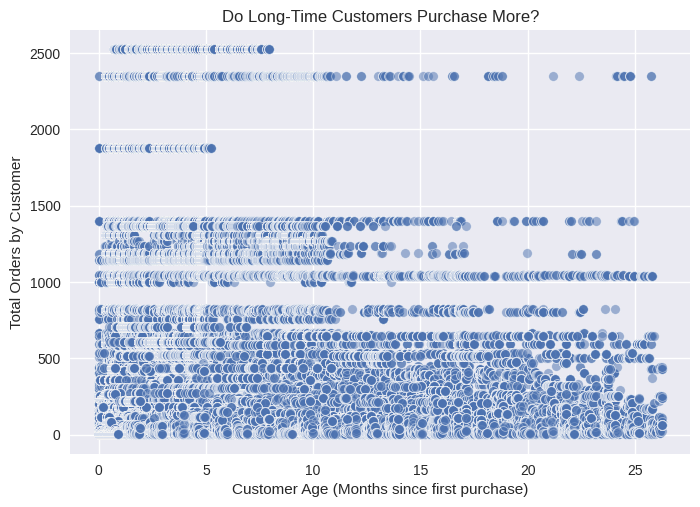

In [394]:
# Cluttered Graph we have to do data reduction
sns.scatterplot(data=df, x='customer_age_months', y='num_orders', alpha=0.5)
plt.xlabel("Customer Age (Months since first purchase)")
plt.ylabel("Total Orders by Customer")
plt.title("Do Long-Time Customers Purchase More?")
plt.show()


### Stratified Sampling

In [395]:
# create bins
df['tenure_bin'] = pd.cut(df['customer_age_months'],
                          bins=[0,5,10,15,20,25,30],
                          labels=['0-5', '5-10', '10-15', '15-20', '20-25', '25+'])


In [396]:
from sklearn.model_selection import train_test_split

# keep only valid rows
clean_df = df.dropna(subset=['tenure_bin'])

# stratified sampling
sample_df, _ = train_test_split(
    clean_df,
    test_size=0.95,
    stratify=clean_df['tenure_bin'],
    random_state=42
)


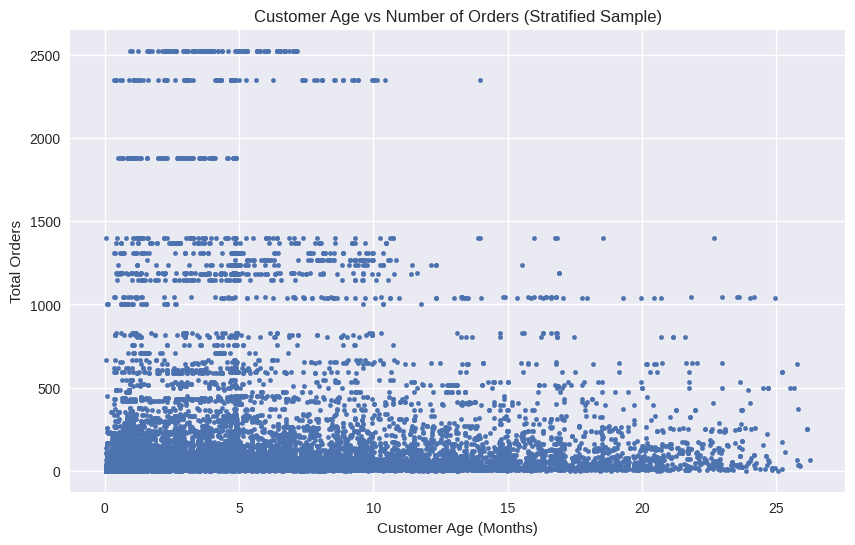

<Axes: xlabel='customer_age_months', ylabel='num_orders'>

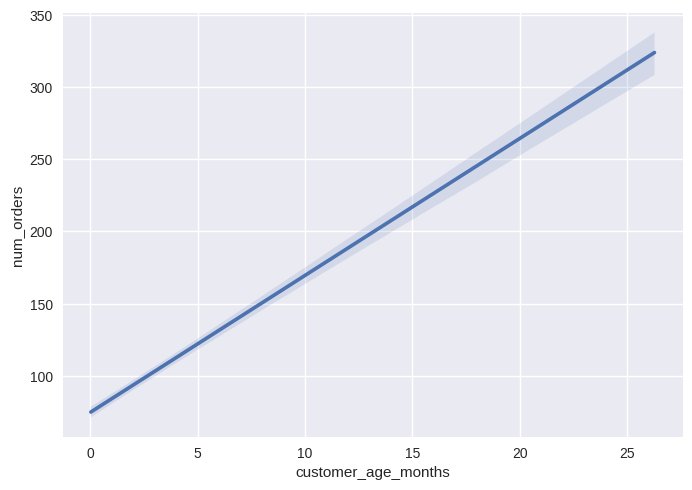

In [397]:
plt.figure(figsize=(10,6))
plt.scatter(sample_df['customer_age_months'],
            sample_df['num_orders'], s=10)

plt.xlabel('Customer Age (Months)')
plt.ylabel('Total Orders')
plt.title('Customer Age vs Number of Orders (Stratified Sample)')
plt.show()
sns.regplot(data=sample_df,x='customer_age_months', y = 'num_orders',scatter=False)


In [398]:
df['order_month'] = df['created_at'].dt.to_period('M')   # Example: 2017-06


In [399]:
monthly_orders = df.groupby('order_month').size().reset_index(name='num_orders')


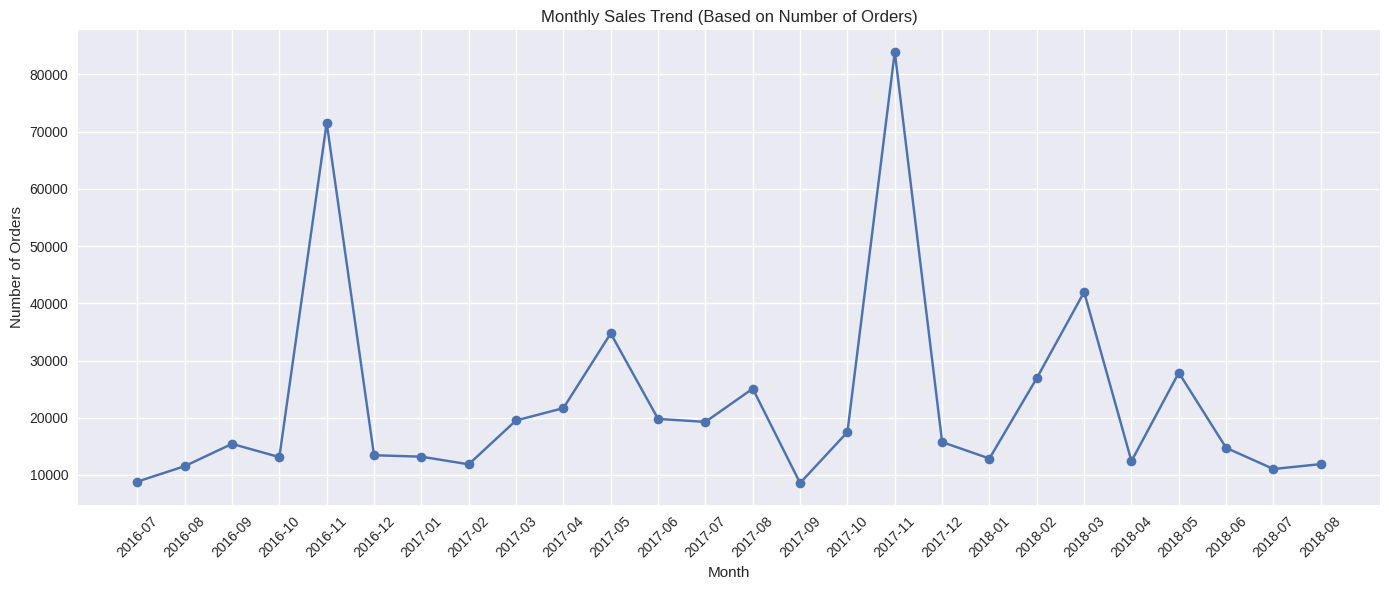

In [400]:
# Daraz 11-11
plt.figure(figsize=(14,6))
plt.plot(monthly_orders['order_month'].astype(str),
         monthly_orders['num_orders'],
         marker='o')

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend (Based on Number of Orders)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipython-input-134726920.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_revenue = df.groupby('category_name')['grand_total'].sum().sort_values(ascending=False).head(10)


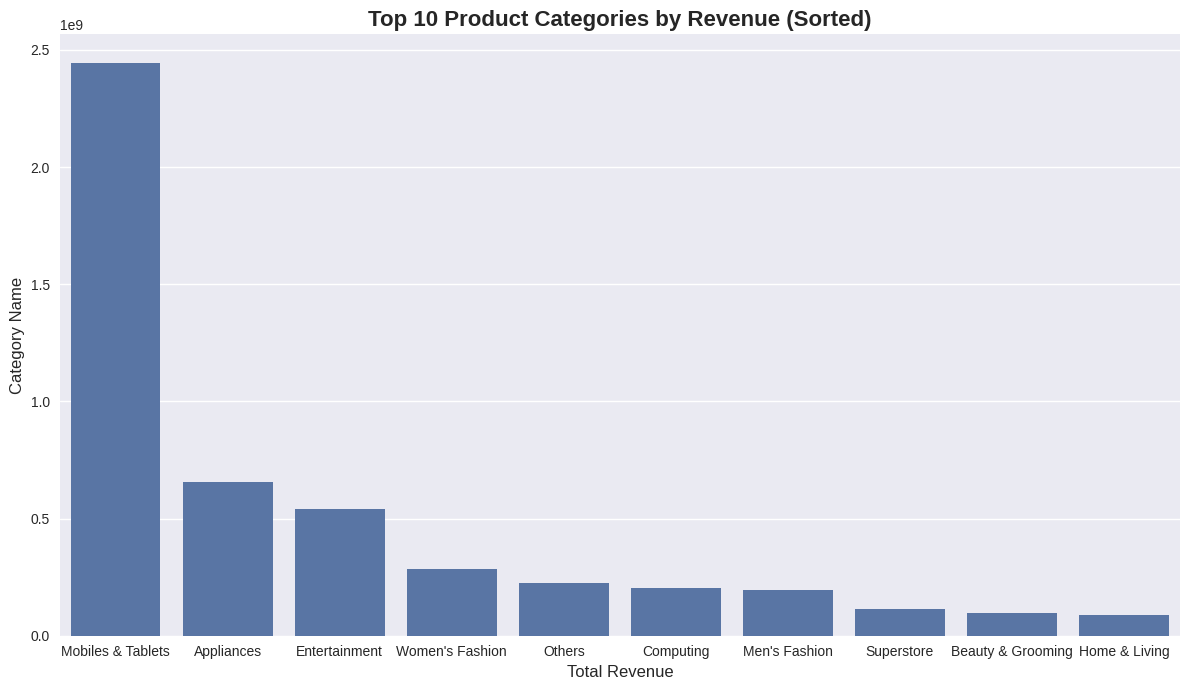

In [404]:
# Which Category contributes most to the revenue
# Group by category and sum the grand total

# 1. Group, sum, and sort the data
category_revenue = df.groupby('category_name')['grand_total'].sum().sort_values(ascending=False).head(10)

# 2. Define the exact order for the y-axis labels
#    This takes the index (category names) of the already-sorted Series.
category_order = category_revenue.index

# 3. Plot the result using the 'order' parameter
plt.style.use('seaborn-v0_8') # Use the recommended clean style

plt.figure(figsize=(12, 7))
sns.barplot(
    y=category_revenue.values,
    x=category_revenue.index,
    order=category_order,
)

# 4. Improve Aesthetics
plt.title('Top 10 Product Categories by Revenue (Sorted)', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Category Name', fontsize=12)

# Use tight_layout to prevent labels from being cut off (addressing the issue in your image)
plt.tight_layout()
plt.show()